<a href="https://colab.research.google.com/github/SyedaFarahJaseemZaidi-ds/CodeAlpha_Data_Analytics_Tasks/blob/main/Task4_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


--- 1. FIRST 10 BOOKS WITH SENTIMENT ---
                                          Book Title Sentiment
0                               A Light in the Attic   Neutral
1                                 Tipping the Velvet   Neutral
2                                         Soumission   Neutral
3                                      Sharp Objects   Neutral
4              Sapiens: A Brief History of Humankind   Neutral
5                                    The Requiem Red   Neutral
6  The Dirty Little Secrets of Getting Your Dream...  Negative
7  The Coming Woman: A Novel Based on the Life of...  Positive
8  The Boys in the Boat: Nine Americans and Their...   Neutral
9                                    The Black Maria   Neutral


--- 2. SENTIMENT COUNT SUMMARY ---
Sentiment
Neutral     13
Positive     5
Negative     2
Name: count, dtype: int64




/tmp/ipykernel_2201/404362797.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette='Set2', order=['Positive', 'Neutral', 'Negative'])


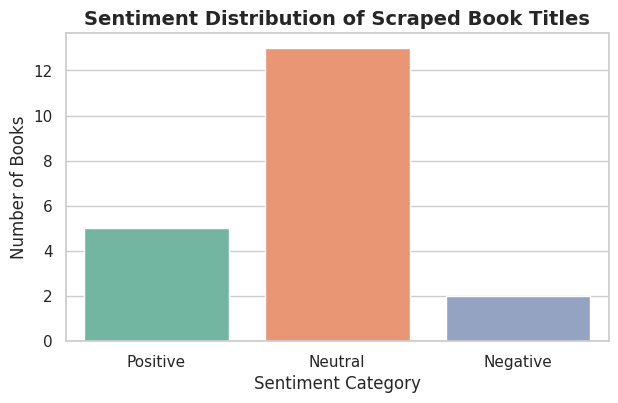

✅ Task 4: Sentiment Analysis Completed Successfully!


In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK VADER lexicon for sentiment analysis
nltk.download('vader_lexicon')

# --- 1. FETCH BOOK TITLES ---
url = "http://books.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

titles = []
books = soup.find_all("article", class_="product_pod")

for book in books:
    titles.append(book.h3.a["title"])

df = pd.DataFrame({"Book Title": titles})

# --- 2. PERFORM SENTIMENT ANALYSIS ---
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment function to book titles
df['Sentiment'] = df['Book Title'].apply(analyze_sentiment)

# Display results
print("--- 1. FIRST 10 BOOKS WITH SENTIMENT ---")
print(df.head(10))
print("\n" + "="*45 + "\n")

print("--- 2. SENTIMENT COUNT SUMMARY ---")
print(df['Sentiment'].value_counts())
print("\n" + "="*45 + "\n")

# --- 3. DATA VISUALIZATION ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Sentiment', palette='Set2', order=['Positive', 'Neutral', 'Negative'])

plt.title("Sentiment Distribution of Scraped Book Titles", fontsize=14, fontweight="bold")
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Books")
plt.savefig("sentiment_distribution.png", bbox_inches='tight')
plt.show()

print("✅ Task 4: Sentiment Analysis Completed Successfully!")